In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

SEED = 42
LABEL_COL = 'Label'
CSV_PATH  = '/kaggle/input/datasets/anshkarki/cyber-dataset-neural-nexus/combined_noisy.csv'
OUT_PATH  = 'engineered_dataset.csv'

In [2]:
df = pd.read_csv(CSV_PATH, low_memory=False)
df.columns = df.columns.str.strip()

DROP_META = ['Flow ID', 'Src IP', 'Dst IP', 'Timestamp']
df.drop(columns=[c for c in DROP_META if c in df.columns], inplace=True)

print(f'Shape after dropping meta cols: {df.shape}')

Shape after dropping meta cols: (1775435, 80)


In [3]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
before = len(df)
df.drop_duplicates(inplace=True)
print(f'Removed {before - len(df):,} duplicate rows. Remaining: {len(df):,}')

Removed 7,304 duplicate rows. Remaining: 1,768,131


In [4]:
feature_cols = [c for c in df.columns if c != LABEL_COL]
numeric_cols = df[feature_cols].select_dtypes(include='number').columns.tolist()

X = df[numeric_cols].copy()
y_raw = df[LABEL_COL].astype(str)

print(f'Numeric features: {len(numeric_cols)}')
print(f'Label classes   : {y_raw.nunique()}')

Numeric features: 70
Label classes   : 1589


In [5]:
imputer = SimpleImputer(strategy='median')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=numeric_cols)

missing_after = X_imp.isnull().sum().sum()
print(f'Missing values after imputation: {missing_after}')

Missing values after imputation: 0


In [6]:
zero_var_cols = [c for c in X_imp.columns if X_imp[c].nunique() <= 1]
print(f'Zero-variance cols removed: {len(zero_var_cols)} → {zero_var_cols}')
X_imp.drop(columns=zero_var_cols, inplace=True)

nzv_cols = [c for c in X_imp.columns
            if X_imp[c].value_counts(normalize=True).iloc[0] > 0.95]
print(f'Near-zero-variance cols removed: {len(nzv_cols)}')
X_imp.drop(columns=nzv_cols, inplace=True)

print(f'Features remaining: {X_imp.shape[1]}')

Zero-variance cols removed: 0 → []
Near-zero-variance cols removed: 6
Features remaining: 64


In [7]:
corr = X_imp.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

to_drop_corr = [col for col in upper.columns if any(upper[col] > 0.90)]
print(f'High-correlation cols removed: {len(to_drop_corr)}')
X_imp.drop(columns=to_drop_corr, inplace=True)

print(f'Features remaining after corr filter: {X_imp.shape[1]}')

High-correlation cols removed: 8
Features remaining after corr filter: 56


In [8]:
def safe_ratio(a, b, fill=0.0):
    denom = b.replace(0, np.nan)
    return (a / denom).fillna(fill)

cols = X_imp.columns.tolist()
engineered = {}
if 'Flow Bytes/s' in cols and 'Flow Pkts/s' in cols:
    engineered['bytes_per_pkt'] = safe_ratio(X_imp['Flow Bytes/s'], X_imp['Flow Pkts/s'])

if 'Fwd Pkts/s' in cols and 'Bwd Pkts/s' in cols:
    total_pkt_rate = X_imp['Fwd Pkts/s'] + X_imp['Bwd Pkts/s']
    engineered['fwd_pkt_ratio'] = safe_ratio(X_imp['Fwd Pkts/s'], total_pkt_rate)

if 'Pkt Len Mean' in cols and 'Pkt Len Std' in cols:
    engineered['pkt_len_cv'] = safe_ratio(X_imp['Pkt Len Std'], X_imp['Pkt Len Mean']) 

if 'Fwd Pkt Len Mean' in cols and 'Bwd Pkt Len Mean' in cols:
    engineered['fwd_bwd_len_diff'] = X_imp['Fwd Pkt Len Mean'] - X_imp['Bwd Pkt Len Mean']


if 'Flow IAT Mean' in cols and 'Flow IAT Std' in cols:
    engineered['iat_cv'] = safe_ratio(X_imp['Flow IAT Std'], X_imp['Flow IAT Mean'])

if 'Active Mean' in cols and 'Idle Mean' in cols:
    engineered['active_idle_ratio'] = safe_ratio(X_imp['Active Mean'], X_imp['Idle Mean'])

skew_feats = X_imp.apply(lambda s: s.skew()).abs()
high_skew  = skew_feats[skew_feats > 5].index.tolist()
for col in high_skew:
    engineered[f'log1p_{col}'] = np.log1p(X_imp[col].clip(lower=0))

print(f'New engineered features: {len(engineered)}')
eng_df = pd.DataFrame(engineered, index=X_imp.index)
X_final = pd.concat([X_imp, eng_df], axis=1)
print(f'Total features after engineering: {X_final.shape[1]}')

New engineered features: 29
Total features after engineering: 85


In [9]:
upper_bounds = X_final.quantile(0.99)
X_final = X_final.clip(upper=upper_bounds, axis=1)
print('Outliers clipped at 99th percentile.')

Outliers clipped at 99th percentile.


In [10]:
scaler = RobustScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_final),
    columns=X_final.columns
)
print(f'Scaled shape: {X_scaled.shape}')

Scaled shape: (1768131, 85)


In [11]:
le = LabelEncoder()
y_encoded = le.fit_transform(y_raw)

label_map = dict(enumerate(le.classes_))
print('Label mapping:')
for k, v in label_map.items():
    print(f'  {k:>2} → {v}')

Label mapping:
   0 → ??
   1 → BBENIGN
   2 → BBot
   3 → BBot - Attempted
   4 → BEENIGN
   5 → BEIGN
   6 → BEINGN
   7 → BENGIN
   8 → BENGN
   9 → BENIG
  10 → BENIGGN
  11 → BENIGN
  12 → BENIGNN
  13 → BENIGaN
  14 → BENIGbN
  15 → BENIGcN
  16 → BENIGdN
  17 → BENIGeN
  18 → BENIGfN
  19 → BENIGgN
  20 → BENIGhN
  21 → BENIGiN
  22 → BENIGjN
  23 → BENIGkN
  24 → BENIGlN
  25 → BENIGmN
  26 → BENIGnN
  27 → BENIGoN
  28 → BENIGpN
  29 → BENIGqN
  30 → BENIGrN
  31 → BENIGsN
  32 → BENIGtN
  33 → BENIGuN
  34 → BENIGvN
  35 → BENIGwN
  36 → BENIGxN
  37 → BENIGyN
  38 → BENIGzN
  39 → BENIIGN
  40 → BENIN
  41 → BENING
  42 → BENIaGN
  43 → BENIbGN
  44 → BENIcGN
  45 → BENIdGN
  46 → BENIeGN
  47 → BENIfGN
  48 → BENIgGN
  49 → BENIhGN
  50 → BENIiGN
  51 → BENIjGN
  52 → BENIkGN
  53 → BENIlGN
  54 → BENImGN
  55 → BENInGN
  56 → BENIoGN
  57 → BENIpGN
  58 → BENIqGN
  59 → BENIrGN
  60 → BENIsGN
  61 → BENItGN
  62 → BENIuGN
  63 → BENIvGN
  64 → BENIwGN
  65 → BENIxGN
  66 →

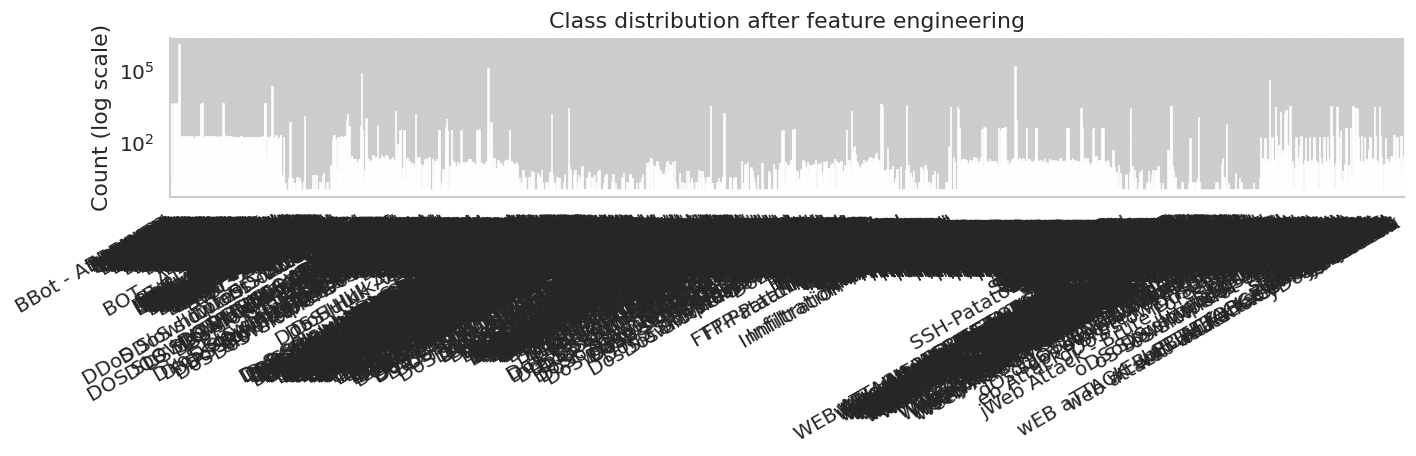

In [12]:
label_counts = pd.Series(y_encoded).value_counts().sort_index()
label_counts.index = [label_map[i] for i in label_counts.index]

fig, ax = plt.subplots(figsize=(12, 4))
label_counts.plot(kind='bar', ax=ax, color=sns.color_palette('muted', len(label_counts)))
ax.set_title('Class distribution after feature engineering')
ax.set_yscale('log')
ax.set_ylabel('Count (log scale)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('fe_class_distribution.png')
plt.show()

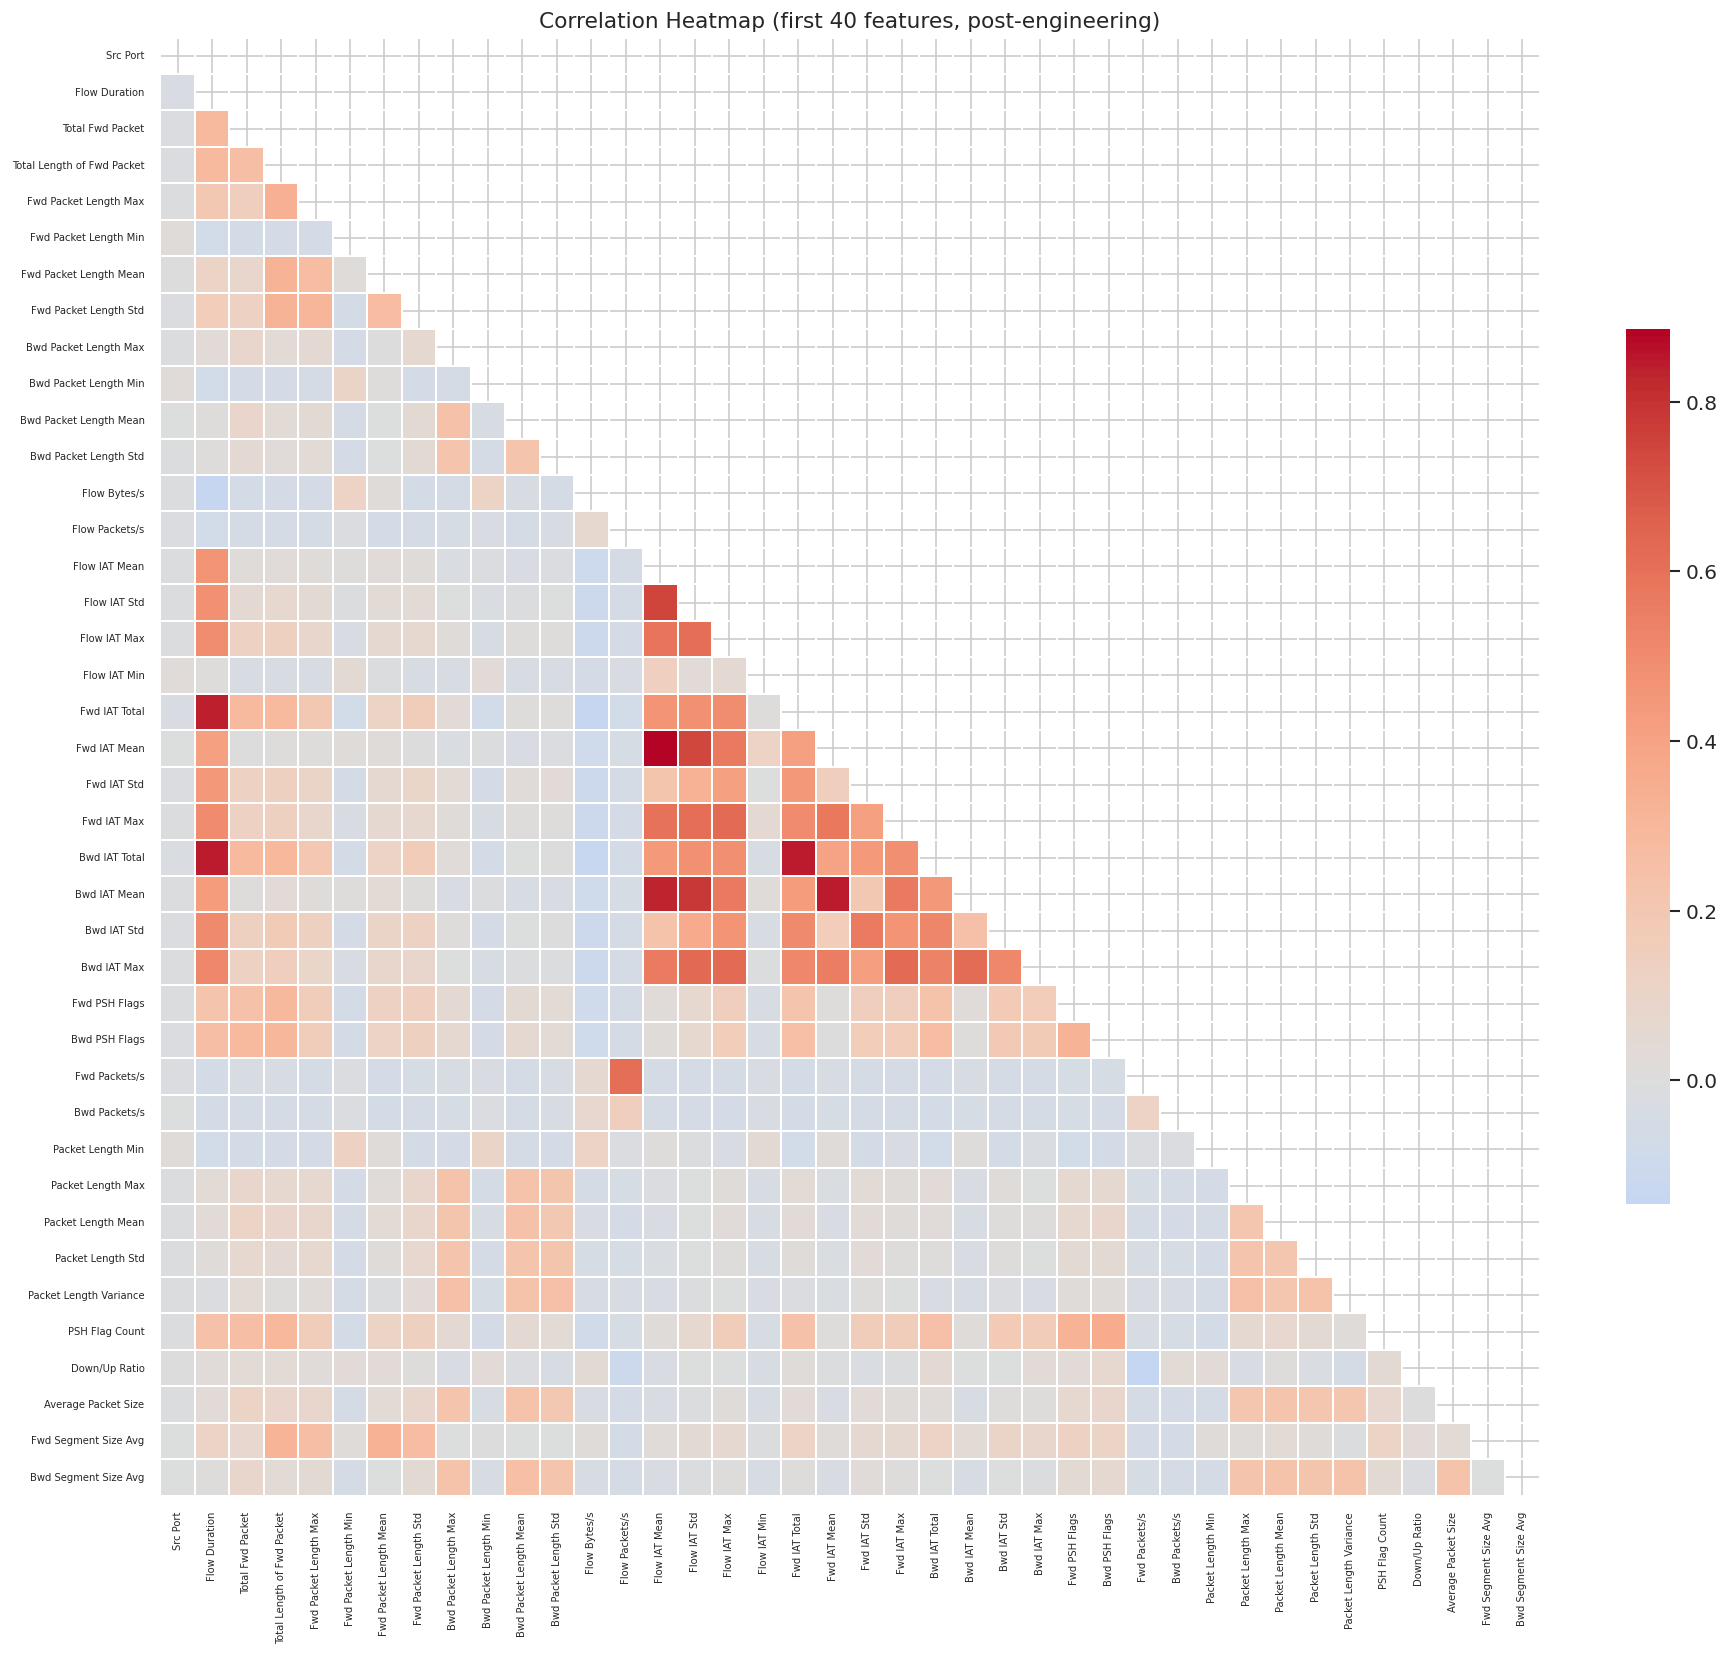

In [13]:
sample_cols = X_scaled.columns[:40]
fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones((len(sample_cols), len(sample_cols)), dtype=bool))
sns.heatmap(
    X_scaled[sample_cols].corr(), mask=mask,
    cmap='coolwarm', center=0, linewidths=0.2,
    ax=ax, cbar_kws={'shrink': 0.6},
    xticklabels=True, yticklabels=True
)
ax.tick_params(axis='x', labelsize=6, rotation=90)
ax.tick_params(axis='y', labelsize=6)
ax.set_title('Correlation Heatmap (first 40 features, post-engineering)', fontsize=13)
plt.tight_layout()
plt.savefig('fe_correlation_heatmap.png', bbox_inches='tight')
plt.show()

In [14]:
out = X_scaled.copy()
out[LABEL_COL] = y_encoded
out.to_csv(OUT_PATH, index=False)

pd.DataFrame(label_map.items(), columns=['encoded', 'original']).to_csv('label_map.csv', index=False)

print('='*60)
print('FEATURE ENGINEERING SUMMARY')
print('='*60)
print(f'  Final rows        : {out.shape[0]:,}')
print(f'  Final features    : {X_scaled.shape[1]}')
print(f'  Label classes     : {len(le.classes_)}')
print(f'  Saved to          : {OUT_PATH}')
print(f'  Label map saved   : label_map.csv')

FEATURE ENGINEERING SUMMARY
  Final rows        : 1,768,131
  Final features    : 85
  Label classes     : 1589
  Saved to          : engineered_dataset.csv
  Label map saved   : label_map.csv
